Shortest Paths from Source Vertex 0
------------------------------------------------------------
Vertex    Distance    Path
------------------------------------------------------------
0         0           0
1         3           0 -> 2 -> 1
2         1           0 -> 2
3         4           0 -> 2 -> 1 -> 3
4         7           0 -> 2 -> 1 -> 3 -> 4
5         9           0 -> 2 -> 1 -> 3 -> 4 -> 5


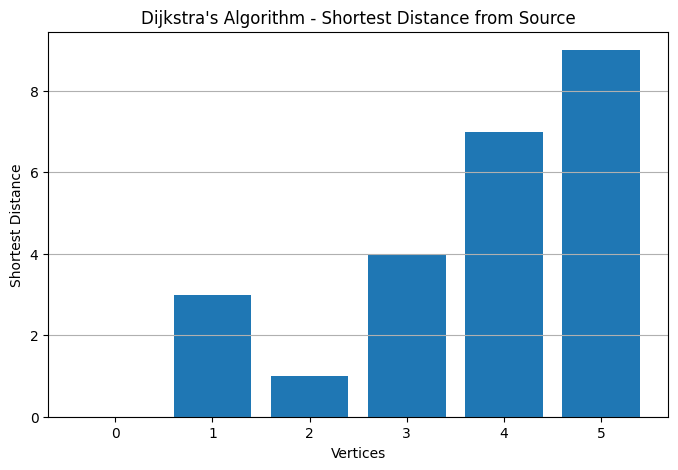

In [ ]:
import heapq
import matplotlib.pyplot as plt

# ---------------- Dijkstra Algorithm ----------------
def dijkstra(graph, source):
    n = len(graph)
    dist = [float('inf')] * n
    prev = [None] * n

    dist[source] = 0
    pq = [(0, source)]
    visited = set()

    while pq:
        d, u = heapq.heappop(pq)

        if u in visited:
            continue

        visited.add(u)

        for v, w in graph[u]:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u
                heapq.heappush(pq, (dist[v], v))

    return dist, prev


# ---------------- Reconstruct Path ----------------
def reconstruct_path(prev, source, target):
    path = []

    while target is not None:
        path.append(target)
        target = prev[target]

    path.reverse()

    if path[0] == source:
        return path

    return []


# ---------------- Graph Definition ----------------
graph = {
    0: [(1, 4), (2, 1)],
    1: [(3, 1)],
    2: [(1, 2), (3, 5)],
    3: [(4, 3)],
    4: [(5, 2)],
    5: []
}

source = 0

# ---------------- Run Dijkstra ----------------
dist, prev = dijkstra(graph, source)

print("Shortest Paths from Source Vertex", source)
print("-" * 60)
print(f"{'Vertex':<10}{'Distance':<12}{'Path'}")
print("-" * 60)

for v in range(len(graph)):
    path = reconstruct_path(prev, source, v)
    path_str = " -> ".join(map(str, path))
    distance = dist[v] if dist[v] != float("inf") else "INF"

    print(f"{v:<10}{distance:<12}{path_str}")


# ---------------- Graph ----------------
vertices = list(range(len(graph)))

plt.figure(figsize=(8,5))

plt.bar(vertices, dist)

plt.title("Dijkstra's Algorithm - Shortest Distance from Source")
plt.xlabel("Vertices")
plt.ylabel("Shortest Distance")
plt.xticks(vertices)
plt.grid(axis='y')

plt.show()